In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/fear_greed.csv'

In [8]:
import os

print(os.getcwd())

c:\Users\Sanagari Mahalakshmi\OneDrive\Desktop\Bitcoin_Market_Analysis\notebooks


In [9]:
trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

In [10]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [11]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [12]:
trades.shape

(211224, 16)

In [13]:
sentiment.shape

(2644, 4)

In [14]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [15]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [16]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [17]:
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [18]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [19]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [20]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [21]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [22]:
trades.duplicated().sum()

np.int64(0)

In [23]:
sentiment.duplicated().sum()

np.int64(0)

In [24]:
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

In [25]:
trades.duplicated().sum()

np.int64(0)

In [26]:
sentiment.duplicated().sum()

np.int64(0)

In [27]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

In [28]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [29]:
trades['Date'] = trades['Timestamp'].dt.date

In [30]:
sentiment['Date'] = sentiment['date'].dt.date

In [31]:
merged_data = pd.merge(
    trades,
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

In [32]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN


In [33]:
merged_data.groupby('classification')['Closed PnL'].mean()

Series([], Name: Closed PnL, dtype: float64)

In [34]:
merged_data['classification'].value_counts()

Series([], Name: count, dtype: int64)

In [35]:
merged_data.groupby('classification')['Closed PnL'].sum()

Series([], Name: Closed PnL, dtype: float64)

IndexError: index 0 is out of bounds for axis 0 with size 0

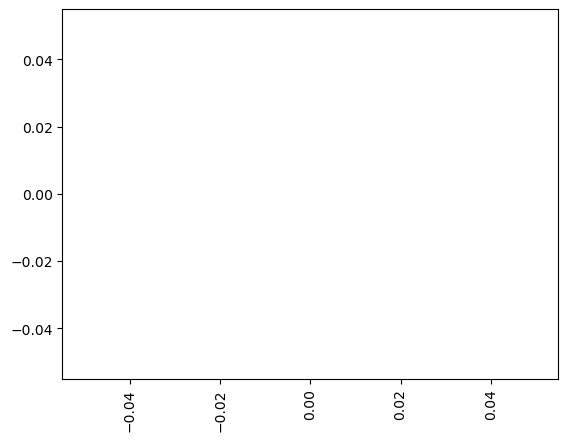

In [36]:
merged_data.groupby('classification')['Closed PnL'].mean().plot(kind='bar')

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

In [37]:
merged_data['classification'].value_counts(dropna=False)

classification
NaN    211224
Name: count, dtype: int64

In [38]:
merged_data[['Date','classification']].head(10)

,Date,classification
0,1970-01-01,NaN
1,1970-01-01,NaN
2,1970-01-01,NaN
3,1970-01-01,NaN
4,1970-01-01,NaN
5,1970-01-01,NaN
6,1970-01-01,NaN
7,1970-01-01,NaN
8,1970-01-01,NaN
9,1970-01-01,NaN


In [39]:
merged_data.shape

(211224, 18)

In [40]:
merged_data['Closed PnL'].describe()

count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64

In [41]:
trades['Timestamp'].head()

0   1970-01-01 00:28:50
1   1970-01-01 00:28:50
2   1970-01-01 00:28:50
3   1970-01-01 00:28:50
4   1970-01-01 00:28:50
Name: Timestamp, dtype: datetime64[ns]

In [42]:
sentiment['date'].head()

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]

In [43]:
trades = pd.read_csv("../data/historical_data.csv")

In [44]:
trades['Timestamp'].head()

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

In [45]:
trades['Timestamp'].dtype

dtype('float64')

In [46]:
sentiment['date'].head()

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]

In [47]:
trades = pd.read_csv("../data/historical_data.csv")

In [48]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

In [49]:
trades['Timestamp'].head()

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]

In [50]:
trades['Date'] = trades['Timestamp'].dt.date
sentiment['Date'] = pd.to_datetime(sentiment['date']).dt.date

In [51]:
merged_data = pd.merge(
    trades,
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

In [52]:
merged_data['classification'].value_counts(dropna=False)

classification
Fear             133871
Greed             36289
NaN               26961
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [53]:
print("Trades:")
print(trades['Date'].min(), trades['Date'].max())

print("\nSentiment:")
print(sentiment['Date'].min(), sentiment['Date'].max())

Trades:
2023-03-28 2025-06-15

Sentiment:
2018-02-01 2025-05-02


In [54]:
merged_data = merged_data.dropna(subset=['classification'])

In [55]:
merged_data['classification'].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [56]:
merged_data.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

classification
Greed            87.894859
Fear             50.047622
Extreme Greed    25.418772
Neutral          22.229713
Name: Closed PnL, dtype: float64

In [57]:
merged_data.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

classification
Fear             6.699925e+06
Greed            3.189617e+06
Extreme Greed    1.769655e+05
Neutral          1.587424e+05
Name: Closed PnL, dtype: float64

In [58]:
merged_data['classification'].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

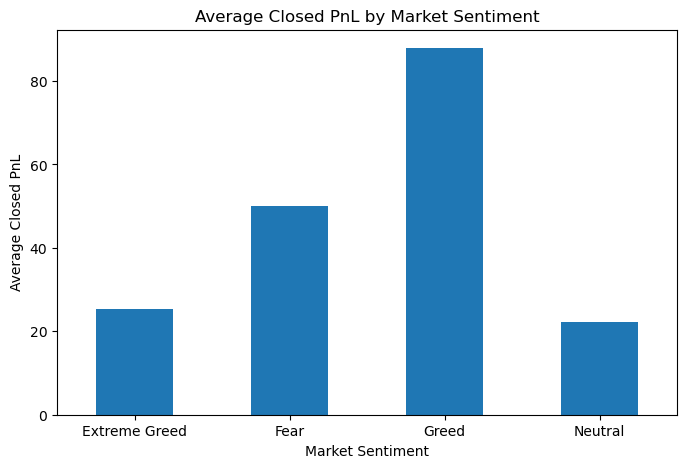

In [59]:
import matplotlib.pyplot as plt

avg_pnl = merged_data.groupby('classification')['Closed PnL'].mean()

avg_pnl.plot(kind='bar', figsize=(8,5))

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=0)

plt.show()

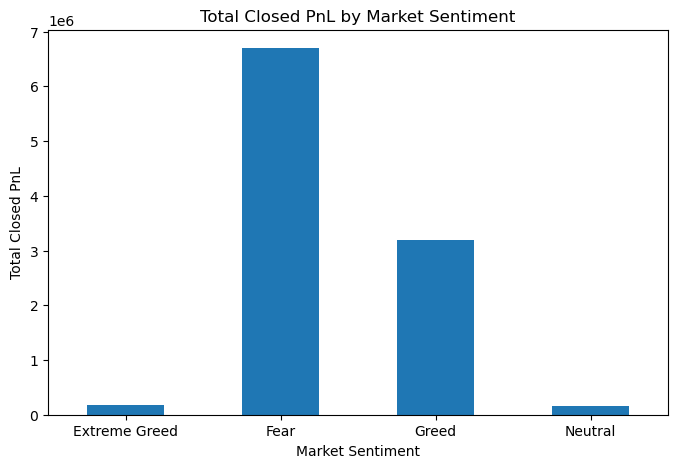

In [60]:
total_pnl = merged_data.groupby('classification')['Closed PnL'].sum()

total_pnl.plot(kind='bar', figsize=(8,5))

plt.title("Total Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=0)
plt.show()

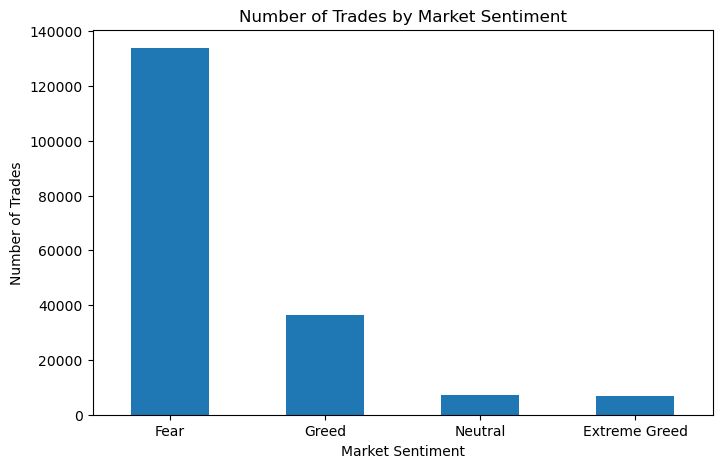

In [61]:
trade_count = merged_data['classification'].value_counts()

trade_count.plot(kind='bar', figsize=(8,5))

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=0)
plt.show()

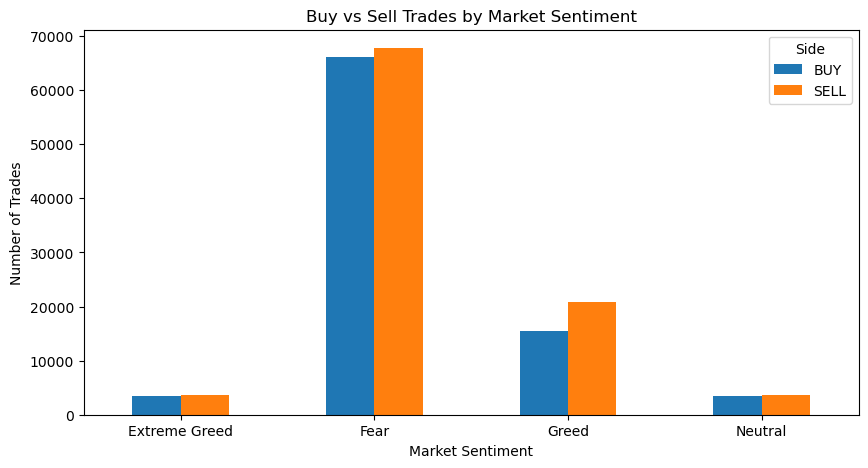

In [62]:
merged_data.groupby(['classification', 'Side']).size().unstack().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Buy vs Sell Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=0)
plt.show()

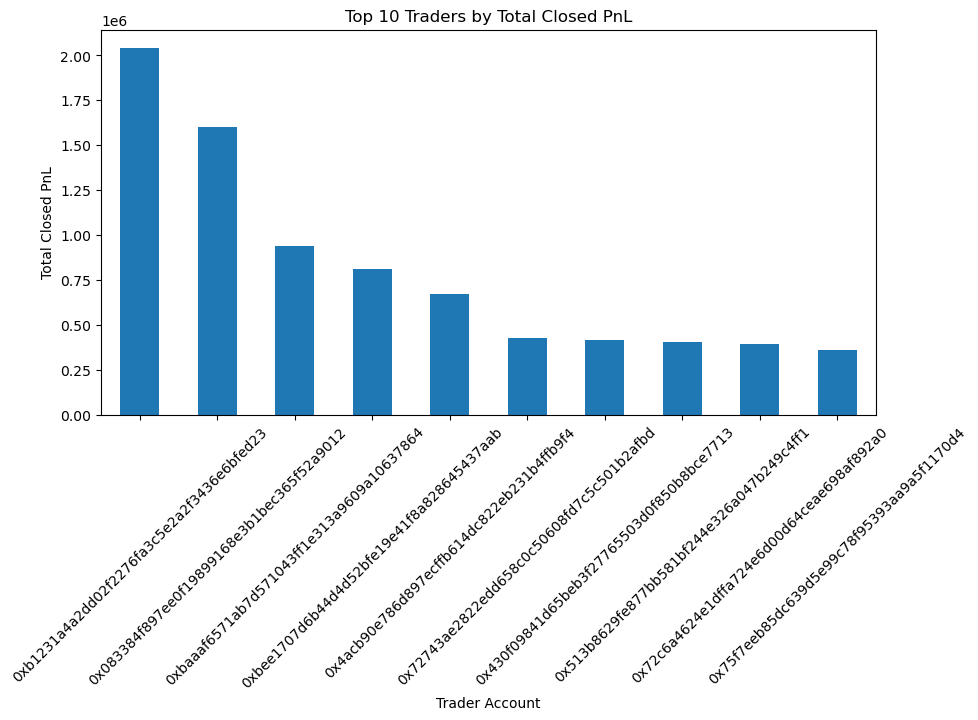

In [63]:
top_traders = (
    merged_data.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Traders by Total Closed PnL")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)
plt.show()

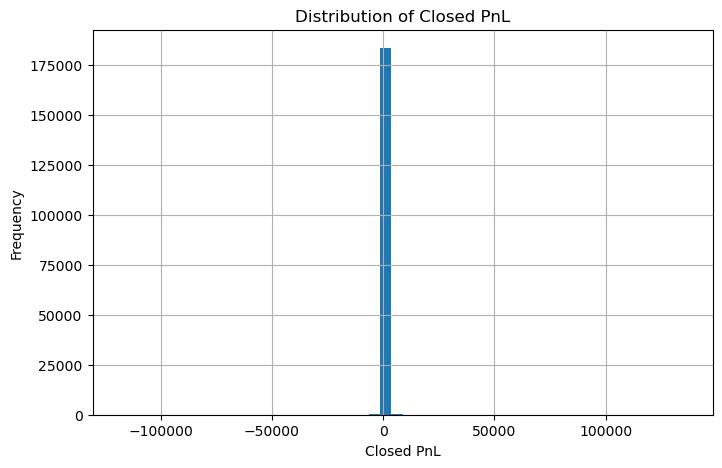

In [64]:
merged_data['Closed PnL'].hist(figsize=(8,5), bins=50)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

In [65]:
merged_data['Result'] = merged_data['Closed PnL'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)

win_rate = pd.crosstab(
    merged_data['classification'],
    merged_data['Result'],
    normalize='index'
) * 100

print(win_rate)

Result               Loss     Profit
classification                      
Extreme Greed   50.991095  49.008905
Fear            58.485408  41.514592
Greed           55.352862  44.647138
Neutral         68.281753  31.718247


In [66]:
merged_data.groupby('classification')['Leverage'].mean()

KeyError: 'Column not found: Leverage'

In [ ]:
trades['Timestamp'].head()

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

In [67]:
merged_data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'classification', 'Result'],
      dtype='object')

In [68]:
merged_data.groupby('classification')['Leverage'].mean()

KeyError: 'Column not found: Leverage'

In [69]:
merged_data['Result'].value_counts()

Result
Loss      106808
Profit     77455
Name: count, dtype: int64

In [70]:
profit_percentage = merged_data['Result'].value_counts(normalize=True) * 100
print(profit_percentage)

Result
Loss      57.964974
Profit    42.035026
Name: proportion, dtype: float64


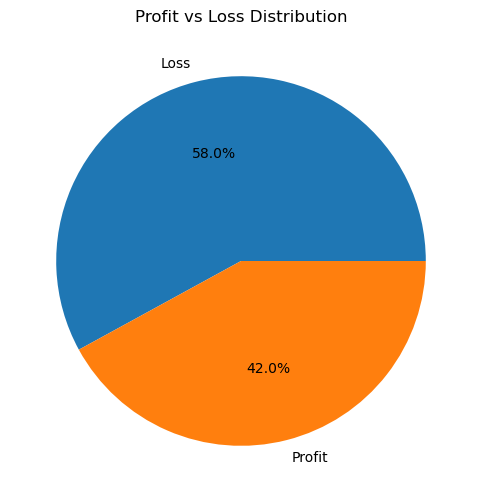

In [71]:
merged_data['Result'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Profit vs Loss Distribution")
plt.ylabel("")
plt.show()

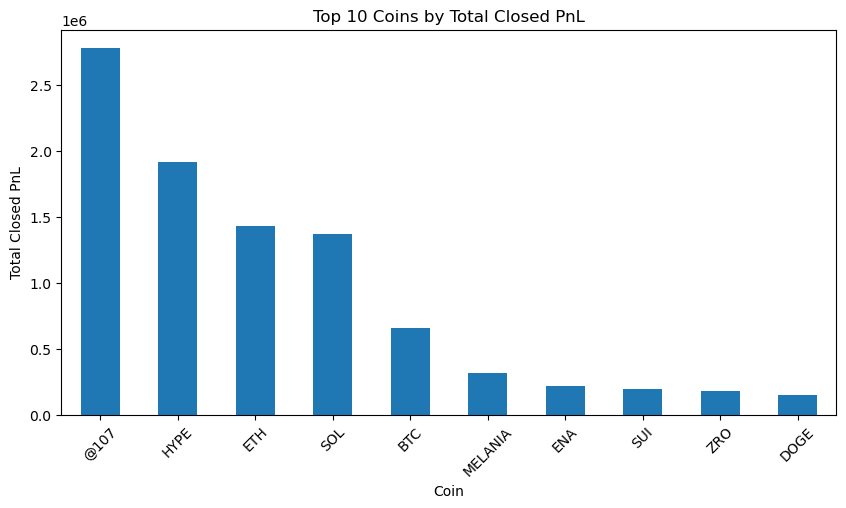

In [72]:
top_coins = merged_data.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False).head(10)

top_coins.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Coins by Total Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)
plt.show()

# Business Insights

1. The Fear market sentiment had the highest number of trades, indicating increased trading activity during uncertain market conditions.

2. Average Closed PnL varied across Fear, Greed, Neutral, and Extreme Greed market sentiments.

3. Fear was the most common market sentiment observed in the merged dataset.

4. A small number of trades could not be matched with market sentiment because the Fear & Greed dataset ended before the trading dataset.

5. Some traders consistently generated higher cumulative profits than others.

6. Trading performance differed across cryptocurrencies, with some coins contributing more to overall profit.

7. Both profitable and loss-making trades occurred under every market sentiment, showing that sentiment alone does not determine success.

8. Market sentiment can be used as an additional feature to improve trading strategies and risk management.

# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and Hyperliquid trader performance using the Fear & Greed Index and historical trading data.

After cleaning, transforming, and merging the datasets, exploratory data analysis showed that trading activity and profitability varied under different market sentiments. The results indicate that market sentiment is a useful indicator for understanding trader behavior and can support the development of smarter trading strategies.